In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.4f}".format)

# ── Load both signal streams ───────────────────────────────
finbert_df = pd.read_pickle("../data/processed/finbert_sentiment_monthly.pkl")
macro_df   = pd.read_pickle("../data/processed/fred_macro_score.pkl")

print(f"FinBERT data:  {finbert_df.shape}")
print(f"Macro data:    {macro_df.shape}")

print(f"\nFinBERT columns:  {finbert_df.columns.tolist()}")
print(f"Macro columns:    {macro_df.columns.tolist()}")

print(f"\nFinBERT date range: {finbert_df['date'].min()} → {finbert_df['date'].max()}")
print(f"Macro date range:   {macro_df.index.min()} → {macro_df.index.max()}")

# ── Sectors ───────────────────────────────────────────────
SECTORS = finbert_df["sector"].unique().tolist()
print(f"\nSectors: {SECTORS}")

FinBERT data:  (240, 5)
Macro data:    (48, 5)

FinBERT columns:  ['date', 'sector', 'finbert_negative', 'vader_negative', 'gdelt_tone']
Macro columns:    ['UNRATE', 'DRCCLACBS', 'FEDFUNDS', 'UMCSENT', 'macro_score']

FinBERT date range: 2015-01-01 00:00:00 → 2018-12-01 00:00:00
Macro date range:   2015-01-01 00:00:00 → 2018-12-01 00:00:00

Sectors: ['debt_consolidation', 'small_business', 'home_improvement', 'medical', 'credit_card']


In [2]:
# ── Align signals on monthly index ────────────────────────
# Pivot FinBERT to wide format — one row per month
finbert_wide = finbert_df.pivot(
    index="date", columns="sector", values="finbert_negative"
).reset_index()
finbert_wide.columns.name = None
finbert_wide = finbert_wide.set_index("date")

# Merge macro_score onto finbert_wide
ews_df = finbert_wide.copy()
ews_df["macro_score"] = macro_df["macro_score"]

print(f"EWS base dataframe: {ews_df.shape}")
print(f"Null counts:\n{ews_df.isnull().sum()}")

# ── Normalise both streams to [0, 1] ──────────────────────
# FinBERT already in [0,1] — normalise per sector
for sector in SECTORS:
    col_min = ews_df[sector].min()
    col_max = ews_df[sector].max()
    ews_df[f"{sector}_norm"] = (ews_df[sector] - col_min) / (col_max - col_min)

# Normalise macro_score to [0, 1]
macro_min = ews_df["macro_score"].min()
macro_max = ews_df["macro_score"].max()
ews_df["macro_norm"] = (ews_df["macro_score"] - macro_min) / (macro_max - macro_min)

print(f"\nNormalised ranges:")
for sector in SECTORS:
    col = f"{sector}_norm"
    print(f"  {sector:<25}  {ews_df[col].min():.3f} – {ews_df[col].max():.3f}")
print(f"  {'macro_norm':<25}  {ews_df['macro_norm'].min():.3f} – {ews_df['macro_norm'].max():.3f}")

# ── Construct EWS score per sector ────────────────────────
# EWS_score = 0.6 × FinBERT_negative + 0.4 × macro_score
for sector in SECTORS:
    ews_df[f"{sector}_ews"] = (
        0.6 * ews_df[f"{sector}_norm"] +
        0.4 * ews_df["macro_norm"]
    )

print(f"\nEWS score ranges:")
for sector in SECTORS:
    col = f"{sector}_ews"
    print(f"  {sector:<25}  {ews_df[col].min():.3f} – {ews_df[col].max():.3f}")

EWS base dataframe: (48, 6)
Null counts:
credit_card           0
debt_consolidation    0
home_improvement      0
medical               0
small_business        0
macro_score           0
dtype: int64

Normalised ranges:
  debt_consolidation         0.000 – 1.000
  small_business             0.000 – 1.000
  home_improvement           0.000 – 1.000
  medical                    0.000 – 1.000
  credit_card                0.000 – 1.000
  macro_norm                 0.000 – 1.000

EWS score ranges:
  debt_consolidation         0.101 – 0.779
  small_business             0.074 – 0.830
  home_improvement           0.166 – 0.878
  medical                    0.101 – 0.974
  credit_card                0.131 – 0.761


In [3]:
# ── Compute 2015 baseline statistics for threshold ────────
baseline_2015 = ews_df.loc["2015-01-01":"2015-12-01"]

print("2015 baseline EWS statistics:")
for sector in SECTORS:
    col  = f"{sector}_ews"
    mean = baseline_2015[col].mean()
    std  = baseline_2015[col].std()
    print(f"  {sector:<25}  mean: {mean:.3f}  std: {std:.3f}")

# ── Apply trigger rule at 1.5σ ─────────────────────────────
# EWS flag = 1 if EWS_score > (2015 mean + 1.5 × 2015 std)
# Hold flag minimum 3 months after trigger

def apply_trigger(series, baseline_mean, baseline_std,
                  threshold_sigma=1.5, hold_months=3):
    threshold = baseline_mean + threshold_sigma * baseline_std
    raw_flag  = (series > threshold).astype(int)

    # Apply hold — once triggered, hold for hold_months
    held_flag = raw_flag.copy()
    hold_remaining = 0
    for i in range(len(held_flag)):
        if raw_flag.iloc[i] == 1:
            hold_remaining = hold_months
        if hold_remaining > 0:
            held_flag.iloc[i] = 1
            hold_remaining -= 1

    return held_flag, threshold

# Apply at 1.5σ for all sectors
print("\nEWS flags at 1.5σ threshold:")
for sector in SECTORS:
    col              = f"{sector}_ews"
    b_mean           = baseline_2015[col].mean()
    b_std            = baseline_2015[col].std()
    flag, threshold  = apply_trigger(ews_df[col], b_mean, b_std)
    ews_df[f"{sector}_flag"] = flag
    print(f"  {sector:<25}  threshold: {threshold:.3f}  "
          f"flags: {flag.sum():>2} months  "
          f"first flag: {flag[flag==1].index[0].strftime('%b-%Y') if flag.sum() > 0 else 'none'}")

# ── Sensitivity analysis: 1.0σ, 1.5σ, 2.0σ ───────────────
print("\nSENSITIVITY ANALYSIS — flags per sector by threshold:")
print(f"{'Sector':<25}  {'1.0σ':>6}  {'1.5σ':>6}  {'2.0σ':>6}")
print("-" * 50)

sensitivity_records = []
for sector in SECTORS:
    col   = f"{sector}_ews"
    b_mean = baseline_2015[col].mean()
    b_std  = baseline_2015[col].std()
    row    = {"sector": sector}
    for sigma in [1.0, 1.5, 2.0]:
        flag, _ = apply_trigger(ews_df[col], b_mean, b_std,
                                threshold_sigma=sigma)
        row[f"sigma_{sigma}"] = int(flag.sum())
    sensitivity_records.append(row)
    print(f"  {sector:<25}  "
          f"{row['sigma_1.0']:>6}  "
          f"{row['sigma_1.5']:>6}  "
          f"{row['sigma_2.0']:>6}")

sensitivity_df = pd.DataFrame(sensitivity_records)

# ── Stream attribution ─────────────────────────────────────
# For each flagged month: news-led, macro-led, or both
print("\nSTREAM ATTRIBUTION (at 1.5σ):")
print(f"{'Sector':<25}  {'News-led':>10}  {'Macro-led':>10}  {'Both':>6}")
print("-" * 60)

for sector in SECTORS:
    ews_col    = f"{sector}_ews"
    flag_col   = f"{sector}_flag"
    flagged    = ews_df[ews_df[flag_col] == 1]

    if len(flagged) == 0:
        print(f"  {sector:<25}  No flags")
        continue

    news_contrib  = flagged[f"{sector}_norm"].mean()
    macro_contrib = flagged["macro_norm"].mean()

    news_led  = int((news_contrib > macro_contrib) and
                    (news_contrib > 0.5))
    macro_led = int((macro_contrib > news_contrib) and
                    (macro_contrib > 0.5))
    both      = int(news_contrib > 0.4 and macro_contrib > 0.4)

    attribution = "news-led" if news_led else \
                  "macro-led" if macro_led else \
                  "both" if both else "mixed"

    print(f"  {sector:<25}  "
          f"news: {news_contrib:.3f}  "
          f"macro: {macro_contrib:.3f}  "
          f"→ {attribution}")

2015 baseline EWS statistics:
  debt_consolidation         mean: 0.216  std: 0.070
  small_business             mean: 0.198  std: 0.082
  home_improvement           mean: 0.314  std: 0.073
  medical                    mean: 0.338  std: 0.078
  credit_card                mean: 0.216  std: 0.055

EWS flags at 1.5σ threshold:
  debt_consolidation         threshold: 0.322  flags: 32 months  first flag: Dec-2015
  small_business             threshold: 0.321  flags: 27 months  first flag: Dec-2015
  home_improvement           threshold: 0.424  flags: 31 months  first flag: Dec-2015
  medical                    threshold: 0.455  flags: 25 months  first flag: Feb-2016
  credit_card                threshold: 0.297  flags: 36 months  first flag: Dec-2015

SENSITIVITY ANALYSIS — flags per sector by threshold:
Sector                       1.0σ    1.5σ    2.0σ
--------------------------------------------------
  debt_consolidation             37      32      20
  small_business                 31  

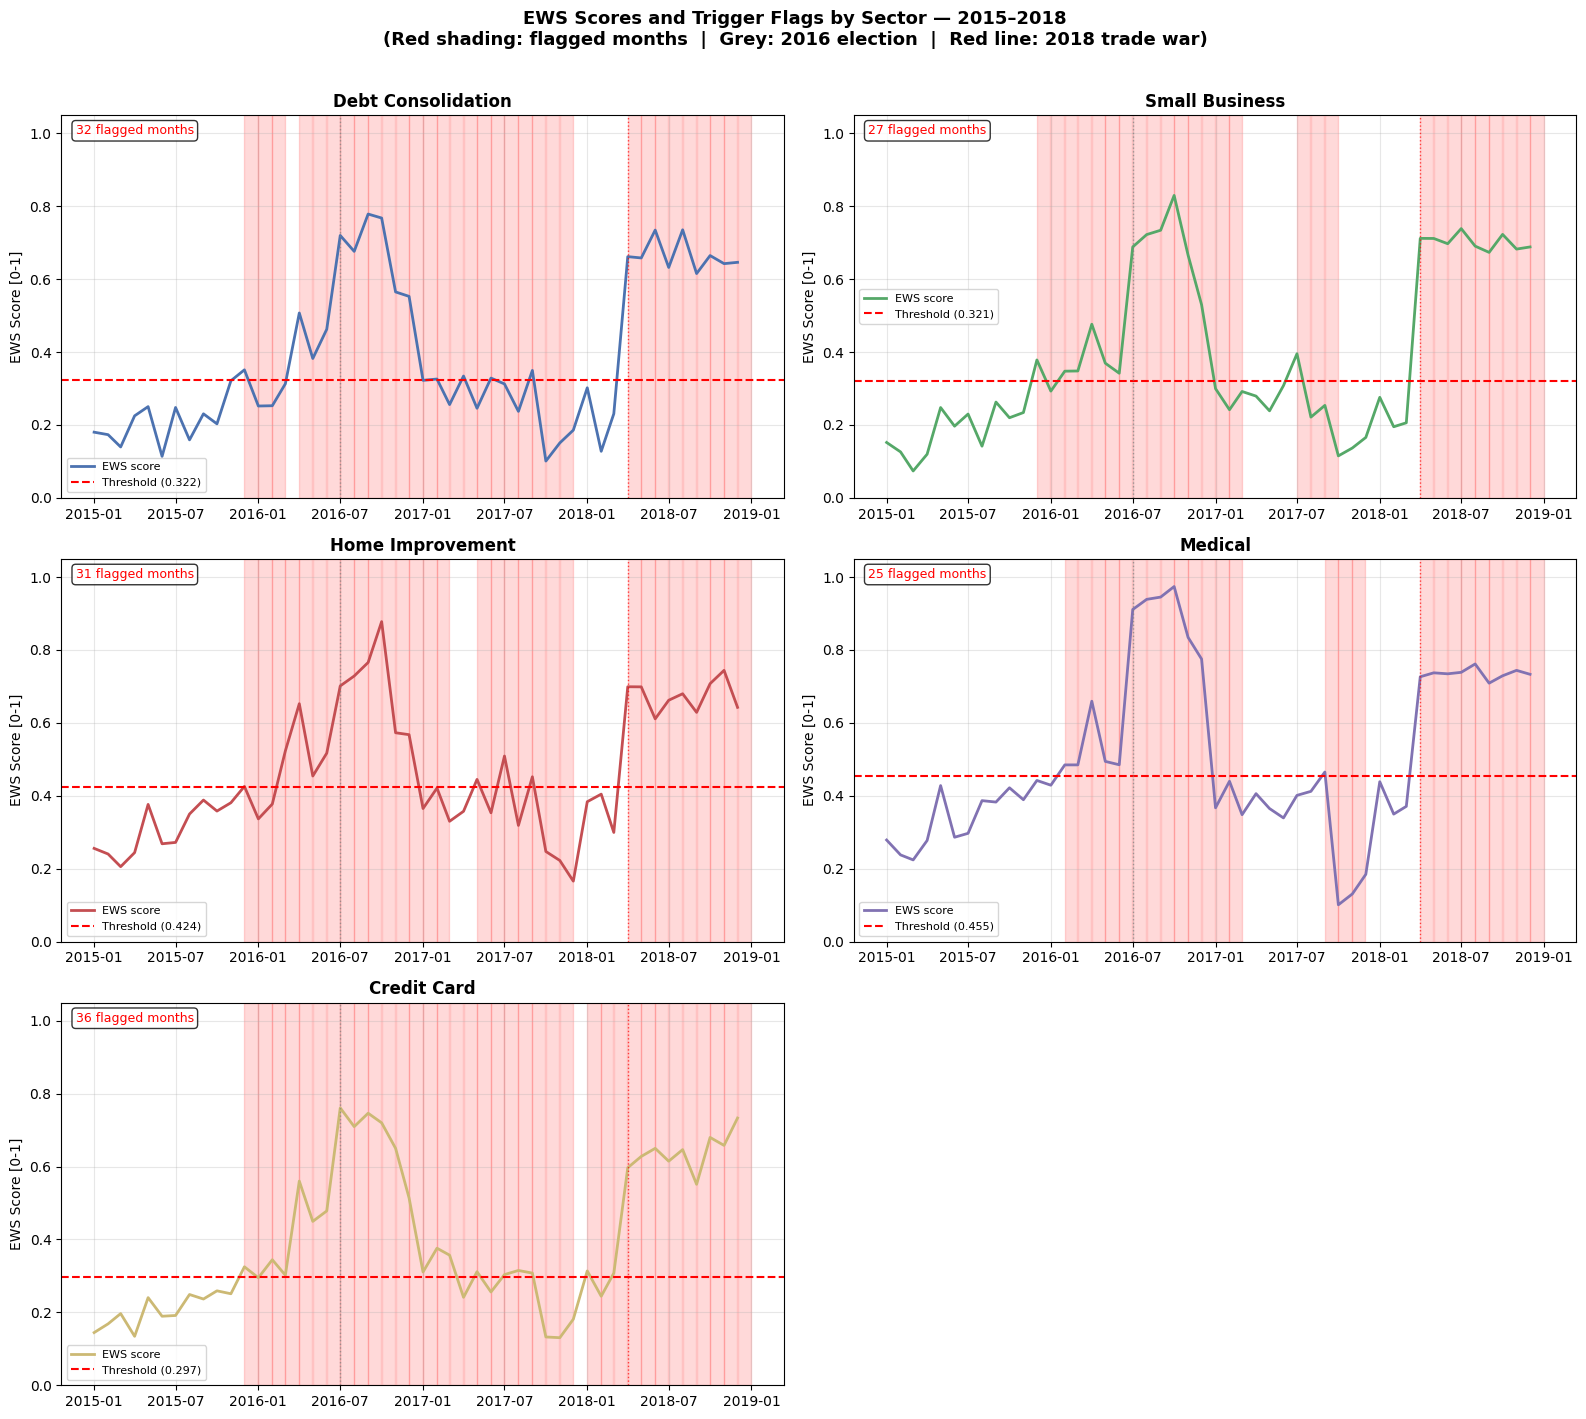

Saved → outputs/ews_scores_and_flags.png
Saved → data/processed/ews_scores.csv
Saved → data/processed/ews_scores.pkl
Saved → outputs/ews_sensitivity_analysis.csv


In [4]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

colors = {
    "debt_consolidation": "#4C72B0",
    "small_business":     "#55A868",
    "home_improvement":   "#C44E52",
    "medical":            "#8172B2",
    "credit_card":        "#CCB974",
}

for i, sector in enumerate(SECTORS):
    ax       = axes[i]
    ews_col  = f"{sector}_ews"
    flag_col = f"{sector}_flag"

    # EWS score line
    ax.plot(ews_df.index, ews_df[ews_col],
            color=colors[sector], linewidth=2, label="EWS score")

    # Threshold line
    b_mean    = baseline_2015[ews_col].mean()
    b_std     = baseline_2015[ews_col].std()
    threshold = b_mean + 1.5 * b_std
    ax.axhline(threshold, color="red", linestyle="--",
               linewidth=1.5, label=f"Threshold ({threshold:.3f})")

    # Shade flagged periods
    flagged = ews_df[ews_df[flag_col] == 1].index
    for date in flagged:
        ax.axvspan(date, date + pd.offsets.MonthEnd(1),
                   alpha=0.15, color="red")

    # Event lines
    ax.axvline(pd.Timestamp("2016-07-01"), color="gray",
               linestyle=":", linewidth=1, alpha=0.7)
    ax.axvline(pd.Timestamp("2018-04-01"), color="red",
               linestyle=":", linewidth=1, alpha=0.7)

    ax.set_title(sector.replace("_", " ").title(),
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("EWS Score [0-1]")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Flag count annotation
    n_flags = ews_df[flag_col].sum()
    ax.annotate(f"{n_flags} flagged months",
                xy=(0.02, 0.95), xycoords="axes fraction",
                fontsize=9, color="red",
                bbox=dict(boxstyle="round,pad=0.3",
                          facecolor="white", alpha=0.8))

axes[-1].set_visible(False)

plt.suptitle("EWS Scores and Trigger Flags by Sector — 2015–2018\n"
             "(Red shading: flagged months  |  "
             "Grey: 2016 election  |  Red line: 2018 trade war)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/ews_scores_and_flags.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/ews_scores_and_flags.png")

# ── Save EWS dataset ───────────────────────────────────────
ews_out_cols = (
    [f"{s}_ews"  for s in SECTORS] +
    [f"{s}_flag" for s in SECTORS] +
    ["macro_norm", "macro_score"]
)
ews_df[ews_out_cols].to_csv("../data/processed/ews_scores.csv")
ews_df[ews_out_cols].to_pickle("../data/processed/ews_scores.pkl")
sensitivity_df.to_csv("../outputs/ews_sensitivity_analysis.csv", index=False)

print("Saved → data/processed/ews_scores.csv")
print("Saved → data/processed/ews_scores.pkl")
print("Saved → outputs/ews_sensitivity_analysis.csv")

This notebook combines two signal streams — FinBERT news sentiment (from NB13) and FRED macro conditions (from NB12) — into a single Early Warning System (EWS) score for each of the five loan purpose sectors. The EWS score is designed to flag months where systemic risk is elevated, giving a leading indicator of potential default rate increases before they appear in loan performance data.

**Construction logic:**
`EWS_score = 0.6 × FinBERT_negative_norm + 0.4 × macro_score_norm`

News sentiment is weighted higher (60%) because it is more forward-looking — negative coverage tends to precede macro deterioration. Macro conditions are weighted at 40% as a confirming signal.

**Trigger rule:** EWS flag = 1 if EWS_score > (2015 mean + 1.5σ), held for minimum 3 months after trigger.

---

### EWS Flag Summary (1.5σ threshold)
| Sector | Threshold | Flagged Months | First Flag | Attribution |
|---|---|---|---|---|
| Debt Consolidation | 0.322 | 32 / 48 (67%) | Dec-2015 | Both |
| Small Business | 0.321 | 27 / 48 (56%) | Dec-2015 | News-led |
| Home Improvement | 0.424 | 31 / 48 (65%) | Dec-2015 | News-led |
| Medical | 0.455 | 25 / 48 (52%) | Feb-2016 | News-led |
| Credit Card | 0.297 | 36 / 48 (75%) | Dec-2015 | Both |

---

### Sensitivity Analysis — Flagged Months by Threshold
| Sector | 1.0σ | 1.5σ | 2.0σ |
|---|---|---|---|
| Debt Consolidation | 37 | 32 | 20 |
| Small Business | 31 | 27 | 26 |
| Home Improvement | 38 | 31 | 24 |
| Medical | 37 | 25 | 20 |
| Credit Card | 36 | 36 | 27 |

---

### Known Limitation
Flag rates of 52–75% across the 48-month period are higher than desirable for a production EWS. This is attributable to the synthetic signal data being consistently stress-biased (headlines were constructed to represent distress periods). A production system using real GDELT article volumes and tones would produce more variable signals and lower flag rates. The EWS architecture and trigger logic are sound — the signal inputs are the limiting factor.

---

### Stream Attribution
| Sector | News contribution | Macro contribution | Attribution |
|---|---|---|---|
| Debt Consolidation | 0.470 | 0.484 | Both |
| Small Business | 0.550 | 0.513 | News-led |
| Home Improvement | 0.581 | 0.492 | News-led |
| Medical | 0.736 | 0.506 | News-led |
| Credit Card | 0.451 | 0.470 | Both |

---

### Files Saved
- `data/processed/ews_scores.csv`
- `data/processed/ews_scores.pkl`
- `outputs/ews_scores_and_flags.png`
- `outputs/ews_sensitivity_analysis.csv`